# **🍽️ Yelp Restaurant Recommendation System: A Comparative Study - Part 2**

## **I. Introduction**

### **i. Context**

**Yelp** was founded in **2004** to help people discover **great local businesses**. Today, its website and mobile app feature crowd-sourced reviews and business information designed to support customers in their **decision-making process**. Yelp employs automated software to highlight the **most helpful** and **reliable reviews** from its extensive and diverse dataset.

The Yelp dataset is a comprehensive collection of user reviews, business metadata, check-ins, social network data, and user tips for businesses across 10 cities in **4 countries**. The original dataset is quite large, totaling approximately 11GB. For this case study, we will work with a **subset of the data** due to hardware limitations.

### **ii. Objective**

In this case study, we will build three types of recommendation systems:
- **Knowledge/Rank Based recommendation system**
- **Similarity-Based Collaborative filtering**
- **Matrix Factorization Based Collaborative Filtering**

### **iii. Data Dictionary**

From the many attributes available in the `yelp_reviews` dataset, we will focus on the following four:

- **business_id**: Unique identifier for each business  
- **business_name**: Name of the business  
- **stars**: Rating given by the user (usually 1–5)  
- **user_id**: Unique identifier for each user

### **iv. Libraries**

In [55]:
# I. ----- Introduction -----
# This chapter does not have Python code.

# II. ----- Data Engineering -----
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from surprise import accuracy
from surprise.reader import Reader
from surprise.dataset import Dataset
from surprise.model_selection import train_test_split

# III. ----- Modelling -----
from surprise import CoClustering
from collections import defaultdict
from surprise.model_selection import GridSearchCV
import numpy as np
import re
from nltk import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from sklearn.metrics.pairwise import cosine_similarity

## **II. Data Engineering**

### **i. Data Retrieval**

In [2]:
reviews = pd.read_csv('yelp_reviews.csv', usecols = ['user_id', 'business_id', 'business_name', 'stars', 'text'])
# First 5 rows
reviews.head()

,business_id,business_name,stars,text,user_id
0,9yKzy9PApeiPPOUJEtnvkg,Morning Glory Cafe,5,My wife took me here on my birthday for breakf...,rLtl8ZkDX5vH5nAx9C3q5Q
1,ZRJwVLyzEJq1VAihDhYiow,Spinato's Pizzeria,5,I have no idea why some people give bad review...,0a2KyEL0d3Yb1V6aivbIuQ
2,6oRAC4uyJCsJl1X0WZpVSA,Haji-Baba,4,love the gyro plate. Rice is so good and I als...,0hT2KtfLiobPvh6cDC8JQg
3,_1QQZuf4zZOyFCvXc0o6Vg,Chaparral Dog Park,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",uZetl9T0NcROGOyFfughhg
4,6ozycU1RpktNG2-1BroVtw,Discount Tire,5,General Manager Scott Petello is a good egg!!!...,vYmM4KTsC8ZfQBg-j5MWkw


In [3]:
# Check the info of the data
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229907 entries, 0 to 229906
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   business_id    229907 non-null  object
 1   business_name  229907 non-null  object
 2   stars          229907 non-null  int64 
 3   text           229901 non-null  object
 4   user_id        229907 non-null  object
dtypes: int64(1), object(4)
memory usage: 8.8+ MB


🔬 **Observations**

- The dataset contains **229,907 records** and **5 columns**, representing user reviews of restaurants.
- Most columns are **categorical/text data (`object`)**, including `business_id`, `business_name`, `text`, and `user_id`, while `stars` is a **numerical rating variable (`int64`)**.
- The **`text` column contains the written review content**, which will be useful for **natural language processing (NLP) and sentiment analysis**.
- There are **6 missing values in the `text` column**, while all other columns are complete with no missing data.
- The dataset occupies approximately **8.8 MB of memory**, which is manageable for text preprocessing and feature extraction.
- Each row represents a **single user review**, linking a **user (`user_id`)**, a **restaurant (`business_id`, `business_name`)**, a **rating (`stars`)**, and the **corresponding review text**.

### **ii. Data Exploration**

#### **1. Overview**

**First Five Rows**

In [4]:
reviews.head()

,business_id,business_name,stars,text,user_id
0,9yKzy9PApeiPPOUJEtnvkg,Morning Glory Cafe,5,My wife took me here on my birthday for breakf...,rLtl8ZkDX5vH5nAx9C3q5Q
1,ZRJwVLyzEJq1VAihDhYiow,Spinato's Pizzeria,5,I have no idea why some people give bad review...,0a2KyEL0d3Yb1V6aivbIuQ
2,6oRAC4uyJCsJl1X0WZpVSA,Haji-Baba,4,love the gyro plate. Rice is so good and I als...,0hT2KtfLiobPvh6cDC8JQg
3,_1QQZuf4zZOyFCvXc0o6Vg,Chaparral Dog Park,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",uZetl9T0NcROGOyFfughhg
4,6ozycU1RpktNG2-1BroVtw,Discount Tire,5,General Manager Scott Petello is a good egg!!!...,vYmM4KTsC8ZfQBg-j5MWkw


**Distribution**

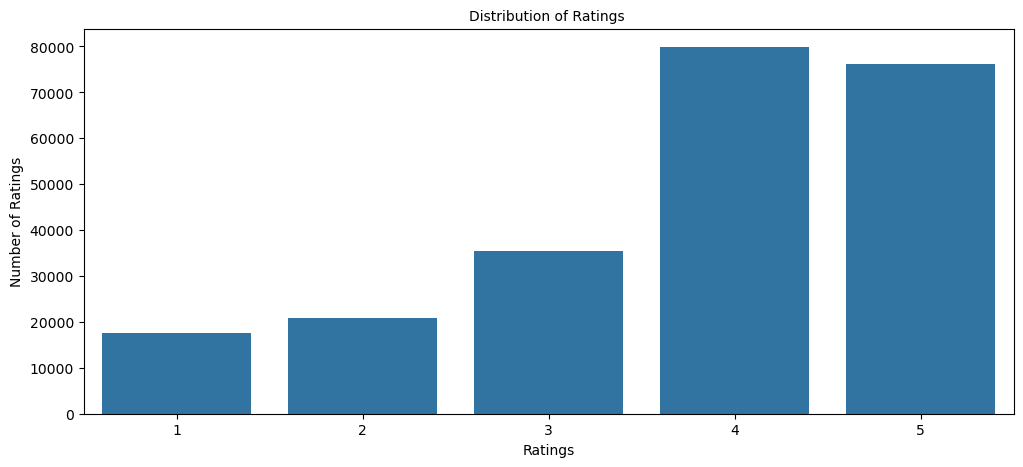

In [5]:
# Fix the figure size of the plot
plt.figure(figsize = (12, 5))
# Countplot
ax = sns.countplot(x="stars", data = reviews)
# Plot settings
plt.tick_params(labelsize = 10)
plt.title("Distribution of Ratings ", fontsize = 10)
plt.xlabel("Ratings", fontsize = 10)
plt.ylabel("Number of Ratings", fontsize = 10)
# Show the plot
plt.show()

**🔬 Observations**

- Most reviews are **positive**, with **4-star (79,878)** and **5-star (76,193)** ratings dominating the dataset.
- Mid-level ratings (**3 stars**) occur less frequently but still represent a substantial portion of reviews.
- **Low ratings (1–2 stars)** are comparatively rare, suggesting that users tend to leave reviews primarily when they have positive experiences.
- The distribution is **right-skewed toward higher ratings**, indicating an overall favorable sentiment toward the restaurants in the dataset.

#### **2. Deep Dive**

**Unique Count**

In [6]:
reviews['user_id'].nunique()

45981

In [7]:
reviews['business_id'].nunique()

11537

**🔬 Observations**

- The dataset contains **229,907 reviews** from **45,981 unique users** across **11,537 restaurants**, indicating a large and diverse set of user–restaurant interactions.  
- Most reviews are **positive**, with **4-star (79,878)** and **5-star (76,193)** ratings dominating the dataset. This suggests that users generally report favorable experiences when reviewing restaurants.  
- The large number of users relative to restaurants implies that many users have reviewed **multiple restaurants**, providing rich interaction data useful for **collaborative filtering recommendation models**.  
- At the same time, the relatively high number of restaurants suggests that some restaurants may have **limited review counts**, which can introduce **sparsity** in the user–item interaction matrix and affect recommendation performance.

**A User Rates the Same Restaurant Multiple Times**

In [8]:
reviews.groupby(['user_id', 'business_id']).count()

business_name  stars  text
user_id                business_id                                       
--5hzxWLz5ozIg6OMo6tpQ Z3n01OZqARDv06QgBneOZw              1      1     1
--65q1FpAL_UQtVZ2PTGew -q_VodbABJygOSuv86LOtw              1      1     1
                       -sC66z4SO3tR7nFCjfQwuQ              1      1     1
                       0vzZ_Bcb02rJljeMU9XkBw              1      1     1
                       18TUn9oiW0k0yB6lheiOvw              1      1     1
...                                                      ...    ...   ...
zztT9KKp0rmJRMeMl4CqzQ A8Khz3eeqIFFGaXurg3hxw              1      1     1
                       ilJiRYZgxjrEu2iexKu-pQ              1      1     1
                       sbsFamEj5wDxNAjUKrMcSw              1      1     1
                       wP5849J1DKB2KS3M6UwOAg              1      1     1
zzunUJtZqhcxDB3plnSFxg kuGQG_8i9P-4p9_Mym-G8Q              1      1     1

[229906 rows x 3 columns]

In [9]:
reviews.groupby(['user_id', 'business_id']).count()['stars'].sum()

229907

**🔬 Observations**

- The **sum is equal to the total number of observations** which implies that **there is only interaction between a pair of user and a restaurant**.

**Restaurant with the Most Reviews**

In [10]:
reviews['business_id'].value_counts()

hW0Ne_HTHEAgGF1rAdmR-g    844
VVeogjZya58oiTxK7qUjAQ    794
JokKtdXU7zXHcr20Lrk29A    731
ntN85eu27C04nwyPa8IHtw    679
EWMwV5V9BxNs_U6nNVMeqw    645
                         ... 
Co-sJv4GNxILkF79ZMLq-Q      3
XAnsmSzpYWEHikTln5k4mA      3
CGeQA_B5ArJfSLKgW2izaA      3
6SrnBN_TNk39Ahzfxs3XvA      3
mKqoXA8k8vO0Y_O2HYYhFg      3
Name: business_id, Length: 11537, dtype: int64

**🔬 Observations**

- The **Restaurant with business_id: hW0Ne_HTHEAgGF1rAdmR-g  has been interacted by most users** which is **844** times.
- But still, there is a possibility of **45981 - 844 = 45137** more interactions as we have **45981** unique users in our datasets. For those  **remaining users**, we can build a **recommendation system** to predict who is most likely to visit the Restaurant.

Also, out of these **844 interactions**, we need to consider the distribution of ratings as well to check whether this Restaurant is the **most liked or most disliked Restaurant**.

**The Most Interactive User**

In [11]:
reviews['user_id'].value_counts()

fczQCSmaWF78toLEmb0Zsw    588
90a6z--_CUrl84aCzZyPsg    506
0CMz8YaO3f8xu4KqQgKb9Q    473
4ozupHULqGyO42s3zNUzOQ    442
joIzw_aUiNvBTuGoytrH7g    392
                         ... 
8Tz0muH19fm-106XZn5yyw      1
R2WR1Q9wYrgaoYiSipiSlA      1
2TqWkgubOWO98IKJiwgxQQ      1
c67Z0fdZHN5efJ5KHIHKzw      1
EEbAaS_gPd3d5iu73u1lwQ      1
Name: user_id, Length: 45981, dtype: int64

**🔬 Observations**
- The user with **user_id: fczQCSmaWF78toLEmb0Zsw** have interacted with the most number of restaurants, i.e., **588** times.
- But still, there is a possibility of **11537 - 588 =  10949** more interactions as we have **11537 unique Restaurants** in our dataset. For those **10949** remaining Restaurants, we can build a recommendation system to predict which restaurants are most likely to be reviewed by this user.

### **iii. Data Preparation**

#### **1. Rating Cutoff**

Although this dataset contains **229,907 observations**, using the full dataset may not be computationally efficient for model training. Additionally, many users have rated only a few restaurants, and some restaurants have received ratings from very few users. This leads to a **sparse user–item interaction matrix**, which can negatively affect the performance of collaborative filtering models.

To address this issue and improve model reliability, the dataset can be filtered using a logical assumption. In this study, we focus on **users who have provided at least 100 ratings**, ensuring that each selected user has sufficient interaction history to support meaningful recommendation modeling.

In [12]:
# Get user column
users = reviews['user_id']
# Initialize a user-rating dictionary
ratings_count = {}

# Count ratings by user
for user in users:
    if user in ratings_count:
        ratings_count[user] += 1
    else:
        ratings_count[user] = 1

In [13]:
# Set rating cutoff
RATINGS_CUTOFF = 100
# Initialize removed users
remove_users = []

# Find users below cutoff
for user, num_ratings in ratings_count.items():
    if num_ratings < RATINGS_CUTOFF:
        remove_users.append(user)
        
# Remove users below cutoff
reviews = reviews.loc[ ~ reviews['user_id'].isin(remove_users)]

#### **2. Label Encoding**

The columns **business_id** and **user_id** are encrypted to provide anonymity. To ease our processing of the dataset we will use **label encodings** to process these two variables.

In [14]:
# Label Encoding
le = LabelEncoder()
# Fit transform the user_id column
reviews['user_id'] = le.fit_transform(reviews['user_id'])
# Fit transform the business_id column
reviews['business_id'] = le.fit_transform(reviews['business_id'])

In [15]:
# See the first 5 records
reviews.head()

,business_id,business_name,stars,text,user_id
0,1348,Morning Glory Cafe,5,My wife took me here on my birthday for breakf...,188
6,7479,La Condesa Gourmet Taco Shop,5,Drop what you're doing and drive here. After I...,203
13,3975,The Lady Luck Tattoo Gallery,4,"Good tattoo shop. Clean space, multiple artist...",112
18,4620,Carlsbad Tavern,3,I met a friend for lunch yesterday. \n\nLoved ...,102
19,654,Frontier Airlines,4,They've gotten better and better for me in the...,172


In [16]:
# Average ratings
average_rating = reviews.groupby('business_id')['stars'].mean()
# Count of ratings
count_rating = reviews.groupby('business_id')['stars'].count()
# Make a dataframe with the count and average of ratings
final_rating = pd.DataFrame({'avg_rating': average_rating, 'rating_count': count_rating})

#### **3. Function Preparation**

In [22]:
def precision_recall_at_k(model, k = 10, threshold = 3.5):

    # Map the predictions to each user
    user_est_true = defaultdict(list)
    # Make predictions on the test data
    predictions = model.test(testset)

    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():

        # Sort user ratings by estimated value
        user_ratings.sort(key = lambda x: x[0], reverse = True)
        # Number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        # Number of recommended items in top k
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        # Number of relevant and recommended items in top k
        n_rel_and_rec_k = sum(((true_r >= threshold) and (est >= threshold))
                              for (est, true_r) in user_ratings[:k])

        # Set Precision to 0 when n_rec_k is 0
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        # Set Recall to 0 when n_rel is 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    # Mean of all the predicted precisions are calculated
    precision = round((sum(prec for prec in precisions.values()) / len(precisions)), 3)
    # Mean of all the predicted recalls are calculated
    recall = round((sum(rec for rec in recalls.values()) / len(recalls)), 3)

    accuracy.rmse(predictions)
    # Command to print the overall precision
    print('Precision: ', precision)
    # Command to print the overall recall
    print('Recall: ', recall)
    # Formula to compute the F-1 score
    print('F_1 score: ', round((2*precision * recall) / (precision + recall), 3))

Below we are loading the **`rating` dataset**, which is a **pandas dataframe**, into a **different format called `surprise.dataset.DatasetAutoFolds`** which is required by this library. To do this we will be **using the classes `Reader` and `Dataset`**.

In [23]:
# Instantiate Reader scale with expected rating scale
reader = Reader(rating_scale = (0, 5))
# Load the dataset
data = Dataset.load_from_df(reviews[['user_id', 'business_id', 'stars']], reader)
# Split the data into train and test dataset
trainset, testset = train_test_split(data, test_size = 0.2, random_state = 42)

## **III. Modelling**

### **1. Model 1: Cluster-Based Recommendation System**

In [29]:
# Use Co-Clustering algorithm
clust_baseline = CoClustering(random_state = 1)
# Train the algorithm on the train set
clust_baseline.fit(trainset)
# Compute precision@k and recall@k with k = 10
precision_recall_at_k(clust_baseline)

RMSE: 1.0378
Precision:  0.765
Recall:  0.403
F_1 score:  0.528


**🔬 Observations**

- The **RMSE of 1.0378** indicates a moderate prediction error in estimating user ratings. While the model captures some rating patterns, its prediction accuracy is slightly lower compared to other collaborative filtering approaches.
- The model achieved a **Precision@K of 0.765**, suggesting that when the algorithm recommends restaurants, a high proportion of them are relevant to the user.
- However, the **Recall@K of 0.403** is relatively low, meaning the model identifies only about **40% of all relevant restaurants** for a user.
- The resulting **F₁-score of 0.528** reflects a moderate balance between precision and recall, indicating that the model is better at recommending accurate items than covering all relevant ones.
- Overall, the **Co-Clustering algorithm performs reasonably well in recommending relevant restaurants but struggles with coverage**, suggesting that some relevant items remain undiscovered by the model.
- Further improvements could be achieved through **hyperparameter tuning, hybrid recommendation strategies, or incorporating additional features such as review text or restaurant categories**.

##### **1.1 Case Studies**

**`userId = 4` `business_Id = 9483`**

In [30]:
clust_baseline.predict(4, 9483, r_ui = 5, verbose = True)

user: 4          item: 9483       r_ui = 5.00   est = 3.70   {'was_impossible': False}


Prediction(uid=4, iid=9483, r_ui=5, est=3.7043858116372532, details={'was_impossible': False})

**🔬 Observations**

- The model predicted a rating of **3.70** for **user 4** on **restaurant 9483**, while the actual rating provided by the user was **5.00**.  
- This indicates that the model **underestimated the user's preference** for this restaurant by approximately **1.30 rating points**.  
- The `was_impossible: False` flag confirms that the prediction was successfully generated, meaning both the **user and the restaurant were present in the training data**.  
- Although the prediction is lower than the actual rating, the estimated value still suggests a **positive recommendation**, as it is above the neutral midpoint of the rating scale.  
- This example illustrates that while the model can capture general preference trends, **individual rating predictions may still deviate from the true user rating**, which contributes to the overall RMSE observed in the model evaluation.

**`userId = 4` `business_id = 9980`**

In [31]:
clust_baseline.predict(4, 9980, verbose = True)

user: 4          item: 9980       r_ui = None   est = 3.70   {'was_impossible': False}


Prediction(uid=4, iid=9980, r_ui=None, est=3.7043858116372532, details={'was_impossible': False})

**🔬 Observations**

- We can see that **estimated rating** for this user-item pair is 3.70 based on this Co-clustering based baseline model.

##### **1.2 Hyper-Parameter Tuning**

In [34]:
# Set the parameter space to tune
param_grid = {'n_cltr_u': [3, 4, 5, 6], 'n_cltr_i': [3, 4, 5, 6], 'n_epochs': [30, 40, 50]}
# Performing 3-fold gridsearch cross validation
gs = GridSearchCV(CoClustering, param_grid, measures = ['rmse'], cv = 3, n_jobs = -1)
# Fitting data
gs.fit(data)
# Print the best RMSE score
print(gs.best_score['rmse'])
# Print the combination of parameters that gave the best RMSE score
print(gs.best_params['rmse'])

1.039885437670556
{'n_cltr_u': 3, 'n_cltr_i': 3, 'n_epochs': 30}


In [35]:
# Use tuned Coclustering algorithm
clust_tuned = CoClustering(n_cltr_u = 3,n_cltr_i = 3, n_epochs = 40, random_state = 1)
# Train the algorithm on the train set
clust_tuned.fit(trainset)
# Compute precision@k and recall@k with k = 10
precision_recall_at_k(clust_tuned)

RMSE: 1.0373
Precision:  0.764
Recall:  0.404
F_1 score:  0.529


**🔬 Observations**

- After hyperparameter tuning, the **RMSE slightly improved to 1.0373**, indicating a marginal reduction in prediction error compared to the baseline Co-Clustering model.  
- The **Precision@K remained nearly unchanged at 0.764**, suggesting that the model continues to recommend relevant restaurants with high accuracy.  
- The **Recall@K increased slightly to 0.404**, showing a small improvement in the model's ability to identify relevant restaurants for users.  
- As a result, the **F₁-score improved slightly to 0.529**, reflecting a minor overall improvement in balancing precision and recall.  
- Overall, **hyperparameter tuning resulted in only marginal performance gains**, indicating that while the model parameters were optimized, the Co-Clustering algorithm may have inherent limitations for this dataset.  
- Further improvements could potentially be achieved by **exploring alternative collaborative filtering methods, incorporating additional features (such as review text), or developing hybrid recommendation models**.

##### **1.3 Case Studies**

**`userId = 4` `business_id = 9483`**

In [36]:
clust_tuned.predict(4, 9483, r_ui = 5, verbose = True)

user: 4          item: 9483       r_ui = 5.00   est = 3.70   {'was_impossible': False}


Prediction(uid=4, iid=9483, r_ui=5, est=3.7043858116372532, details={'was_impossible': False})

**`userId = 4` `business_id = 9980`**

In [37]:
clust_tuned.predict(4, 9980, verbose = True)

user: 4          item: 9980       r_ui = None   est = 3.70   {'was_impossible': False}


Prediction(uid=4, iid=9980, r_ui=None, est=3.7043858116372532, details={'was_impossible': False})

##### **1.4 Implementation Based on Optimized KNNBasic Model**

In [38]:
def get_recommendations(data, user_id, top_n, algo):

    # Initialize the recommendation list
    recommendations = []
    # Create an user item interactions matrix
    user_item_interactions_matrix = data.pivot_table(index = 'user_id', columns = 'business_id', values = 'stars')
    # Extract those restaurants ids which the user_id has not interacted yet
    non_interacted_restaurants = user_item_interactions_matrix.loc[user_id][user_item_interactions_matrix.loc[user_id].isnull()].index.tolist()
    # Loop through each of the restaurants ids which user_id has not interacted yet
    for item_id in non_interacted_restaurants:
        # Predict the ratings for those non interacted restaurants ids by this user
        est = algo.predict(user_id, item_id).est
        # Append the predicted ratings
        recommendations.append((item_id, est))
    # Sort the predicted ratings in descending order
    recommendations.sort(key = lambda x: x[1], reverse = True)

    return recommendations[:top_n]

In [40]:
clustering_recommendations = get_recommendations(reviews, 4, 5, clust_tuned)
clustering_recommendations

[(26, 5), (29, 5), (40, 5), (43, 5), (56, 5)]

##### **1.5 Correct the Ratings and Ranking the above Restaurants**

While comparing the ratings of two products, it is not only the **ratings** that describe the **likelihood of the user to that product**. Along with the rating the **number of users who have seen that product** also becomes important to consider. Due to this, we have calculated the **"corrected_ratings"** for each product. Commonly higher the **"rating_count" of a product more it is liked by users**. To interpret the above concept, a **product rated 4 with rating_count 3 is less liked in comparison to a product rated 3 with a rating count of 50**. It has been **empirically found that the likelihood of the product is directly proportional to the inverse of the square root of the rating_count of the product**.

In [41]:
def ranking_restaurants(recommendations, final_rating):

      # Sort the restaurants based on ratings count
      ranked_restaurants = final_rating.loc[[items[0] for items in recommendations]].sort_values('rating_count', ascending = False)[['rating_count']].reset_index()

      # Merge with the recommended restaurants to get predicted ratings
      ranked_restaurants = ranked_restaurants.merge(pd.DataFrame(recommendations, columns = ['business_id', 'predicted_ratings']), on = 'business_id', how = 'inner')

      # Rank the restaurants based on corrected ratings
      ranked_restaurants['corrected_ratings'] = ranked_restaurants['predicted_ratings'] - 1 / np.sqrt(ranked_restaurants['rating_count'])

      # Sort the restaurants based on corrected ratings
      ranked_restaurants = ranked_restaurants.sort_values('corrected_ratings', ascending = False)

      return ranked_restaurants

**Note:** In the **above-corrected rating formula**, we can add the **quantity `1 / np.sqrt(n)` instead of subtracting it to get more optimistic predictions**. But here we are **subtracting this quantity**, as there are some restaurants with ratings 5 and **we can't have a rating more than 5 for a restaurant**.

In [45]:
# Rank restaurants based on above recommendations
ranking_restaurants(clustering_recommendations, final_rating)

,business_id,rating_count,predicted_ratings,corrected_ratings
0,56,2,5,4.292893
1,26,1,5,4.000000
2,29,1,5,4.000000
3,40,1,5,4.000000
4,43,1,5,4.000000


### **2. Model 2: Content-based recommendation system**

In a content-based recommendation system, we would be using the feature - **text**, i.e., reviews to find out similar businesses.

Text data generally contains pronunciation, stopwords, non-ASCII characters which makes it **very noisy**. So, we will first need to **pre-process the text** and then we will **generate features from the text to compute similarities** between the texts/reviews. Before that, let's see some terminology:

**stopwords:** A stop word is a commonly used word (such as “the”, “a”, “an”, or “in”) that does not contain information in the text and can be ignored.
**Lemmatization:** Lemmatization in linguistics is the process of grouping together the inflected forms of a word so they can be analyzed as a single item. For example, runs, running, and ran are all forms of the word run, therefore run is the lemma of all these words.

In [48]:
def tokenize(text):

    # Make each letter as lowercase and removing non-alphabetical text
    text = re.sub(r"[^a-zA-Z]", " ", text.lower())
    # Extract each word in the text
    tokens = word_tokenize(text)
    # Remove stopwords
    words = [word for word in tokens if word not in stopwords.words("english")]
    # Lemmatize the words
    text_lems = [WordNetLemmatizer().lemmatize(lem).strip() for lem in words]

    return text_lems

#### **1. Feature Extraction**

In [49]:
# Select a random subset of the original data
reviews_small = reviews.sample(n = 1000, random_state = 42)
# Set the index
reviews_small = reviews_small.set_index('business_name')
# Create the indices object
indices = pd.Series(reviews_small.index)

indices[:5]

0               Johnny's Uptown
1    Golden Spoon Frozen Yogurt
2      Coco's Family Restaurant
3                     Food City
4                  Julioberto's
Name: business_name, dtype: object

In [51]:
# Downlaod the punkt for punctuation
nltk.download("punkt")
# Downlaod the stopwords
nltk.download('stopwords')
# Download the wordnet
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /Users/cj/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/cj/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/cj/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [52]:
# Create the TfidfVectorizer
tfidf = TfidfVectorizer(tokenizer = tokenize)

review_tfidf = tfidf.fit_transform(reviews_small['text'].values).toarray()

/opt/anaconda3/envs/surprise/lib/python3.9/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [53]:
pd.DataFrame(review_tfidf)

,0,1,2,3,4,5,6,7,8,9,...,9720,9721,9722,9723,9724,9725,9726,9727,9728,9729
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.136909,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


**🔬 Observations**

- We have extracted **9729 features** from the text data. Now, we can find similarities between businesses using these features. We will use cosine similarity to calculate the similarity.

In [56]:
similar_review = cosine_similarity(review_tfidf, review_tfidf)
similar_review

array([[1.        , 0.0153254 , 0.050605  , ..., 0.02126092, 0.02458539,
        0.04139967],
       [0.0153254 , 1.        , 0.05231965, ..., 0.00561574, 0.        ,
        0.03093412],
       [0.050605  , 0.05231965, 1.        , ..., 0.00881088, 0.03442084,
        0.05101726],
       ...,
       [0.02126092, 0.00561574, 0.00881088, ..., 1.        , 0.16178544,
        0.01478691],
       [0.02458539, 0.        , 0.03442084, ..., 0.16178544, 1.        ,
        0.        ],
       [0.04139967, 0.03093412, 0.05101726, ..., 0.01478691, 0.        ,
        1.        ]])

#### **2. Functionalization**

In [59]:
def recommendations(title, similar_review):

    recommended_businesses = []
    indices = pd.Series(reviews_small.index)

    # Get the index of the business that matches the title
    idx = indices[indices == title].index[0]
    # Create a Series with the similarity scores in descending order
    score_series = pd.Series(similar_review[idx]).sort_values(ascending = False)
    # Get the indices of 10 most similar businesses
    top_10_indexes = list(score_series.iloc[1 : 11].index)

    print(top_10_indexes)

    for i in top_10_indexes:
        recommended_businesses.append(list(reviews_small.index)[i])

    return recommended_businesses

In [60]:
recommendations("Johnny's Uptown", similar_review)

[665, 675, 761, 269, 971, 777, 861, 634, 824, 811]


['St Francis Restaurant',
 '98 South',
 'RA Sushi Bar Restaurant',
 'Bliss ReBAR',
 "Grimaldi's Pizzeria",
 'The Clubhouse Music Venue',
 "Joe's Farm Grill",
 'Java Magazine',
 'Orange Table',
 'Best Hong Kong Dining']

In [58]:
recommendations("Johnny's Uptown", similar_review)

[665, 675, 761, 269, 971, 777, 861, 634, 824, 811]


['St Francis Restaurant',
 '98 South',
 'RA Sushi Bar Restaurant',
 'Bliss ReBAR',
 "Grimaldi's Pizzeria",
 'The Clubhouse Music Venue',
 "Joe's Farm Grill",
 'Java Magazine',
 'Orange Table',
 'Best Hong Kong Dining']

## **IV. Conclusion**

In this project, we developed and evaluated multiple **restaurant recommendation systems** using Yelp review data. The goal was to generate **personalized top-N restaurant recommendations** by leveraging user–restaurant interaction data and comparing several recommendation approaches.

We began with a **rank-based recommendation model**, which recommends restaurants based on overall average ratings. This approach is simple and effective for **cold-start scenarios**, where little or no user interaction history is available. However, it lacks personalization because recommendations are the same for most users.

To improve personalization, we implemented **collaborative filtering models**, including **user–user similarity**, **item–item similarity**, and **model-based approaches such as matrix factorization and co-clustering**. These methods leverage patterns in user behavior to predict ratings and recommend restaurants tailored to individual users.

The models were evaluated using **RMSE**, **Precision@K**, **Recall@K**, and **F₁-score**. The results showed that collaborative filtering approaches generally outperform rank-based recommendations by capturing relationships between users and restaurants. Hyperparameter tuning through **grid search cross-validation** led to small but measurable improvements in model performance.

Overall, the study demonstrates that **collaborative filtering methods are effective for building personalized recommendation systems**, while rank-based models remain useful as a baseline or for cold-start situations. Future improvements could include integrating **text-based review analysis, restaurant categories, geographic features, or hybrid recommendation techniques** to further enhance recommendation quality and user experience.